
# Test del modello Sandpile (`SpreadPy.Models.sandpile`)

Verifiche di correttezza del modello, in formato notebook. Ogni cella stampa `PASS`
se le asserzioni reggono **e** produce una figura di controllo. Coprono: proprietà
abeliana, soglia `strict`, massa massima stabile + rilevamento divergenza,
conservazione dei grani con sink, dissipazione di bulk `f`.

In [1]:
import sys; sys.path.insert(0, '..')
import numpy as np, networkx as nx, random
import matplotlib.pyplot as plt
from SpreadPy.Models.sandpile import SandpileSpreading
print("modello importato:", SandpileSpreading)

modello importato: <class 'SpreadPy.Models.sandpile.SandpileSpreading'>


## Test 1 — Proprietà abeliana (commutatività delle aggiunte)

Il sandpile abeliano (Dhar 1990): la configurazione stabile finale **non dipende
dall'ordine** con cui si aggiungono i grani. Aggiungiamo lo stesso multiset di grani
in due ordini diversi e verifichiamo che lo stato finale sia identico.

In [2]:
G = nx.cycle_graph(8)
SINK = 0

def final_status(drop_seq):
    sp = SandpileSpreading(G, sink=SINK, f=0)
    sp.iteration()                                   # iter 0 = config iniziale
    for node in drop_seq:
        r = sp.iteration(node=node)
        assert not r["diverged"], "non deve divergere (c'e' il sink)"
    return {n: sp.status[n] for n in G.nodes if n != SINK}

base = [1, 2, 3, 4, 5, 6, 7] * 3                     # multiset di 21 grani
shuffled = base[:]; random.Random(0).shuffle(shuffled)

a = final_status(base)
b = final_status(shuffled)
assert a == b, (a, b)
print("PASS — config finale indipendente dall'ordine di aggiunta:", a)


PASS — config finale indipendente dall'ordine di aggiunta: {1: 2, 2: 2, 3: 2, 4: 1, 5: 2, 6: 2, 7: 2}


## Test 2 — Soglia di toppling `strict`

`strict=True` (default): il nodo crolla quando altezza $> \deg$ (stabile fino a
$\deg$). `strict=False`: crolla quando altezza $\geq \deg$ (BTW classico, stabile
fino a $\deg-1$). Su una stella (centro di grado 4) verifichiamo la soglia esatta.

In [3]:
G = nx.star_graph(4)                                 # nodo 0 = centro, grado 4
for strict, thr in [(True, 5), (False, 4)]:
    sp = SandpileSpreading(G, sink=None, f=0, strict=strict)
    sp.status = {n: 0 for n in G.nodes}
    sp.status[0] = thr - 1
    assert sp._unstable(sp.status) == [], f"strict={strict}: stabile a {thr-1}"
    sp.status[0] = thr
    assert 0 in sp._unstable(sp.status), f"strict={strict}: instabile a {thr}"
    print(f"PASS — strict={strict}: centro (grado 4) stabile a {thr-1}, instabile a {thr}")

PASS — strict=True: centro (grado 4) stabile a 4, instabile a 5
PASS — strict=False: centro (grado 4) stabile a 3, instabile a 4


## Test 3 — `max_stable_mass` e rilevamento del regime caotico

In un sistema **chiuso** (sink=None, f=0) la massa massima stabile è
$\sum_v \deg(v)$ (strict) oppure $\sum_v (\deg(v)-1)$ (classico). Oltre quel tetto il
sistema **deve** divergere. La figura mostra il totale dei grani $\sigma_\text{tot}(t)$:
nel chiuso cresce fino al tetto e **diverge**, con il sink invece satura sotto il tetto.

PASS — strict=True: max_stable_mass=12 (atteso 12), diverge all'iter 12
PASS — strict=False: max_stable_mass=6 (atteso 6), diverge all'iter 6


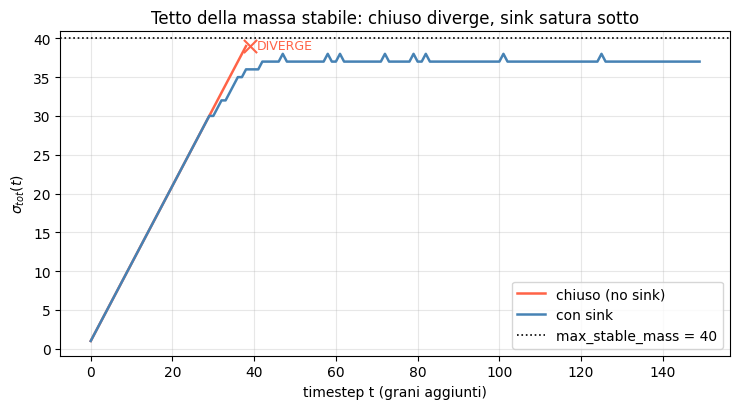

In [4]:
for strict in [True, False]:
    G = nx.cycle_graph(6)                            # ogni nodo grado 2
    sp = SandpileSpreading(G, sink=None, f=0, strict=strict)
    expected = (sum(d for _, d in G.degree()) if strict
                else sum(d - 1 for _, d in G.degree()))
    assert sp.max_stable_mass == expected, (sp.max_stable_mass, expected)
    sp.iteration(); np.random.seed(0); div = None
    for i in range(1, 4 * sp.max_stable_mass):
        if sp.iteration(node=None)["diverged"]:
            div = i; break
    assert div is not None and div <= sp.max_stable_mass + 2, (strict, div)
    print(f"PASS — strict={strict}: max_stable_mass={sp.max_stable_mass} "
          f"(atteso {expected}), diverge all'iter {div}")

# figura: sigma_tot(t) per chiuso (diverge al tetto) vs con sink (plateau sotto il tetto)
G = nx.cycle_graph(20)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for label, sk, col in [("chiuso (no sink)", None, "tomato"), ("con sink", 0, "steelblue")]:
    sp = SandpileSpreading(G, sink=sk, f=0); sp.iteration(); np.random.seed(0)
    tot = []
    for t in range(150):
        r = sp.iteration(node=None)
        if r["diverged"]:
            ax.scatter([t], [tot[-1]], marker="x", s=90, color=col, zorder=5)
            ax.annotate("DIVERGE", (t, tot[-1]), color=col, fontsize=9,
                        xytext=(5, -2), textcoords="offset points")
            break
        tot.append(r["total_grains"])
    ax.plot(range(len(tot)), tot, color=col, lw=1.8, label=label)
ceiling = SandpileSpreading(G, sink=None, f=0).max_stable_mass
ax.axhline(ceiling, color="k", ls=":", lw=1.2, label=f"max_stable_mass = {ceiling}")
ax.set_xlabel("timestep t (grani aggiunti)"); ax.set_ylabel(r"$\sigma_{tot}(t)$")
ax.set_title("Tetto della massa stabile: chiuso diverge, sink satura sotto")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Test 4 — Conservazione dei grani e dissipazione al sink

Con $f=0$ l'unico canale di perdita è il sink: i grani aggiunti = grani nel sistema
+ grani assorbiti dal sink. Il nodo sink non accumula mai (resta a 0).

In [5]:
G = nx.path_graph(6)
SINK = 5
sp = SandpileSpreading(G, sink=SINK, f=0)
sp.iteration()
added = 0; np.random.seed(1)
for _ in range(300):
    r = sp.iteration(node=None)
    if r["diverged"]:
        break
    added += 1
in_system = sum(sp.status.values())
absorbed = added - in_system
assert sp.status[SINK] == 0, "il sink non deve accumulare grani"
assert absorbed >= 0 and in_system >= 0
print(f"PASS — grani aggiunti={added}  nel sistema={in_system}  "
      f"assorbiti dal sink={absorbed}  (sink resta a 0)")


PASS — grani aggiunti=300  nel sistema=9  assorbiti dal sink=291  (sink resta a 0)


## Test 5 — Dissipazione di bulk `f` (senza sink)

Con $f>0$ ogni grano trasferito sparisce con probabilità $f$: la dissipazione di
bulk basta a evitare la divergenza anche **senza** sink, se $f$ è sufficiente. La
figura confronta $\sigma_\text{tot}(t)$ per $f=0$ (diverge) e $f=0.05$ (satura).

PASS — f=0 diverge, f=0.05 resta stazionario senza sink


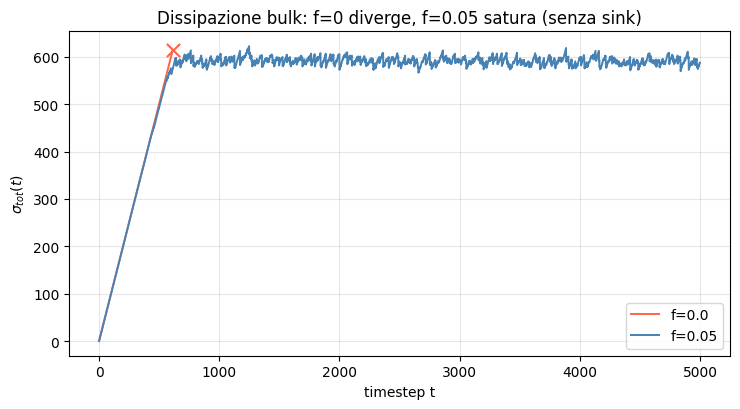


Tutti i test superati.


In [6]:
G = nx.random_regular_graph(4, 200, seed=3)
fig, ax = plt.subplots(figsize=(7.5, 4.2))
results = {}
for f, col in [(0.0, "tomato"), (0.05, "steelblue")]:
    np.random.seed(0)
    sp = SandpileSpreading(G, sink=None, f=f); sp.iteration()
    tot = []; diverged = False
    for _ in range(5000):
        r = sp.iteration(node=None)
        if r["diverged"]:
            diverged = True
            ax.scatter([len(tot)], [tot[-1]], marker="x", s=90, color=col, zorder=5)
            break
        tot.append(r["total_grains"])
    results[f] = diverged
    ax.plot(range(len(tot)), tot, color=col, lw=1.4, label=f"f={f}")
assert results[0.0] is True,  "con f=0 (chiuso) deve divergere"
assert results[0.05] is False, "con f=0.05 NON deve divergere"
print("PASS — f=0 diverge, f=0.05 resta stazionario senza sink")
ax.set_xlabel("timestep t"); ax.set_ylabel(r"$\sigma_{tot}(t)$")
ax.set_title("Dissipazione bulk: f=0 diverge, f=0.05 satura (senza sink)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("\nTutti i test superati.")